# Last Mile Delivery Delay Root Cause Analysis

## MiniHack: AI Data Intelligence Challenge

This notebook analyzes one year of simulated last-mile delivery orders across Indian cities. The objective is to transform raw delivery data into actionable business insights using Python, data cleaning, exploratory data analysis, statistical testing, visualization, and a basic machine learning model.

## Business Goal

Delivery delays affect customer satisfaction, rider productivity, and operating cost. This project identifies the strongest delay drivers and recommends one practical operational fix.

## Key Questions

- Do peak-hour orders experience significantly higher delays?
- How do weather conditions affect delivery delay?
- Does rider experience meaningfully affect delay?
- Which cities and vehicle types need operational attention?
- Can a basic ML model predict whether an order will be delayed?

## 1. Setup

This cell imports the libraries required for data analysis, visualization, statistics, and machine learning. If a package is missing, the notebook attempts to install it automatically.

In [1]:
import sys
import subprocess
import importlib

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "sklearn": "scikit-learn"
}

for module_name, package_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

print("Setup complete.")

Setup complete.


## 2. Data Loading and First Look

The dataset is loaded from the project folder. The first inspection checks the number of records, columns, sample rows, and data types.

In [2]:
df = pd.read_csv("last_mile_delivery_dataset.csv")

print("Rows and columns:", df.shape)
display(df.head())

Rows and columns: (2080, 20)


,order_id,order_date,order_time,city,zone,rider_id,vehicle_type,order_type,distance_km,promised_delivery_mins,actual_delivery_mins,delay_mins,delivery_status,weather_condition,order_value_inr,delivery_attempts,rider_experience_yrs,rider_rating,gps_latitude,gps_longitude
0,ORD000001,2024-09-02,13:10,Chennai,East,RID0022,Cycle,Electronics,11.05,60,57.4,-2.6,On-Time,Partly Cloudy,377.96,1,7.9,4.6,28.9867,87.3825
1,ORD000002,2024-09-13,14:53,Delhi,East,RID0100,cycle,Electronics,14.75,30,29.7,-0.3,On-Time,Clear,1352.80,1,0.4,4.5,36.7618,84.6386
2,ORD000003,2024-02-28,18:01,Lucknow,NaN,RID0010,Bike,Documents,11.21,60,87.0,27.0,Delayed,Clear,1302.15,2,7.8,3.4,NaN,NaN
3,ORD000004,2024-07-13,14:59,Chennai,North,RID0050,AUTO,Documents,10.27,30,57.2,27.2,Delayed,Rain,3308.73,1,6.8,4.4,17.7429,71.3316
4,ORD000005,2024-07-24,14:28,Jaipur,South,RID0078,Bike,Apparel,13.07,60,55.5,-4.5,On-Time,Partly Cloudy,3095.74,2,1.1,3.1,22.9501,96.4950


In [3]:
display(df.info())
display(df.describe(include="all").T)

<class 'pandas.DataFrame'>
RangeIndex: 2080 entries, 0 to 2079
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                2080 non-null   str    
 1   order_date              2080 non-null   str    
 2   order_time              2080 non-null   str    
 3   city                    2080 non-null   str    
 4   zone                    1944 non-null   str    
 5   rider_id                1967 non-null   str    
 6   vehicle_type            2080 non-null   str    
 7   order_type              2080 non-null   str    
 8   distance_km             2080 non-null   float64
 9   promised_delivery_mins  2080 non-null   int64  
 10  actual_delivery_mins    2080 non-null   str    
 11  delay_mins              2080 non-null   float64
 12  delivery_status         2080 non-null   str    
 13  weather_condition       2080 non-null   str    
 14  order_value_inr         2080 non-null   float64
 15

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,2080,2080,ORD000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,2080,365,2024-02-24,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_time,2080,892,06:24,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,2080,17,Lucknow,221,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zone,1944,5,Central,411,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rider_id,1967,150,RID0011,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_type,2080,10,Bike,228,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_type,2080,6,Grocery,363,NaN,NaN,NaN,NaN,NaN,NaN,NaN
distance_km,2080.0,NaN,NaN,NaN,15.809817,47.64693,0.5,5.045,9.475,14.125,496.96
promised_delivery_mins,2080.0,NaN,NaN,NaN,61.485577,22.999148,30.0,45.0,60.0,90.0,120.0


## 3. Data Quality Check

Before analysis, we check missing values, duplicates, and inconsistent category names. This step is important because messy categories such as `bike`, `BIKE`, and `Bike` can create incorrect grouped results.

In [4]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]

print("Duplicate rows:", df.duplicated().sum())
display(missing_values.to_frame("missing_count"))

Duplicate rows: 0


,missing_count
gps_latitude,137
gps_longitude,137
zone,136
rider_id,113


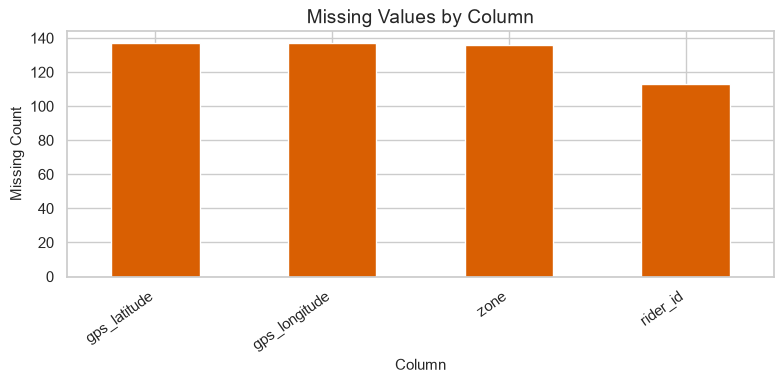

In [5]:
plt.figure(figsize=(8, 4))
missing_values.plot(kind="bar", color="#d95f02")
plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Missing Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 4. Data Cleaning and Feature Engineering

Cleaning decisions:

- Missing `zone` and `rider_id` are filled as `Unknown` because they are identifiers/categories.
- Missing GPS values are filled with median values.
- Text columns are standardized with consistent capitalization and spacing.
- City spelling variants are corrected.
- Date and time columns are converted into analysis-ready features such as `hour`, `month`, and `is_peak_hour`.
- Delay outliers are flagged using the IQR method instead of being deleted, because extreme delays are operationally important.

In [6]:
data = df.copy()

# Fill missing values
data["zone"] = data["zone"].fillna("Unknown")
data["rider_id"] = data["rider_id"].fillna("Unknown")
data["gps_latitude"] = data["gps_latitude"].fillna(data["gps_latitude"].median())
data["gps_longitude"] = data["gps_longitude"].fillna(data["gps_longitude"].median())

# Standardize text columns
text_columns = ["vehicle_type", "weather_condition", "city", "order_type", "zone", "delivery_status"]
for col in text_columns:
    data[col] = data[col].astype(str).str.strip().str.title()

# Correct common city spelling variants
data["city"] = data["city"].replace({
    "Bangaluru": "Bangalore",
    "Hydrabad": "Hyderabad"
})

# Convert dates and times
data["order_date"] = pd.to_datetime(data["order_date"])
data["hour"] = pd.to_datetime(data["order_time"], format="%H:%M").dt.hour
data["month_num"] = data["order_date"].dt.month
data["month"] = data["order_date"].dt.month_name()
data["day_of_week"] = data["order_date"].dt.day_name()
data["is_weekend"] = data["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

# Peak hour definition from problem statement
data["time_period"] = np.where(
    ((data["hour"] >= 8) & (data["hour"] <= 10)) | ((data["hour"] >= 17) & (data["hour"] <= 20)),
    "Peak Hours",
    "Off-Peak Hours"
)
data["is_peak_hour"] = (data["time_period"] == "Peak Hours").astype(int)

# Target for ML
data["delayed_flag"] = (data["delivery_status"] == "Delayed").astype(int)
data["on_time_flag"] = (data["delivery_status"] == "On-Time").astype(int)

# Delay outlier flag using IQR
q1 = data["delay_mins"].quantile(0.25)
q3 = data["delay_mins"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
data["delay_outlier"] = ((data["delay_mins"] < lower_bound) | (data["delay_mins"] > upper_bound)).astype(int)

print("Cleaning complete.")
print("Remaining missing values:", int(data.isnull().sum().sum()))
print("Delay outliers flagged:", int(data["delay_outlier"].sum()))
print("Outlier bounds:", round(lower_bound, 2), "to", round(upper_bound, 2))
display(data.head())

Cleaning complete.
Remaining missing values: 0
Delay outliers flagged: 40
Outlier bounds: -43.05 to 68.55


,order_id,order_date,order_time,city,zone,rider_id,vehicle_type,order_type,distance_km,promised_delivery_mins,...,hour,month_num,month,day_of_week,is_weekend,time_period,is_peak_hour,delayed_flag,on_time_flag,delay_outlier
0,ORD000001,2024-09-02,13:10,Chennai,East,RID0022,Cycle,Electronics,11.05,60,...,13,9,September,Monday,0,Off-Peak Hours,0,0,1,0
1,ORD000002,2024-09-13,14:53,Delhi,East,RID0100,Cycle,Electronics,14.75,30,...,14,9,September,Friday,0,Off-Peak Hours,0,0,1,0
2,ORD000003,2024-02-28,18:01,Lucknow,Unknown,RID0010,Bike,Documents,11.21,60,...,18,2,February,Wednesday,0,Peak Hours,1,1,0,0
3,ORD000004,2024-07-13,14:59,Chennai,North,RID0050,Auto,Documents,10.27,30,...,14,7,July,Saturday,1,Off-Peak Hours,0,1,0,0
4,ORD000005,2024-07-24,14:28,Jaipur,South,RID0078,Bike,Apparel,13.07,60,...,14,7,July,Wednesday,0,Off-Peak Hours,0,0,1,0


## 5. Exploratory Data Analysis

This section gives a broad view of delivery performance before answering the specific challenge questions.

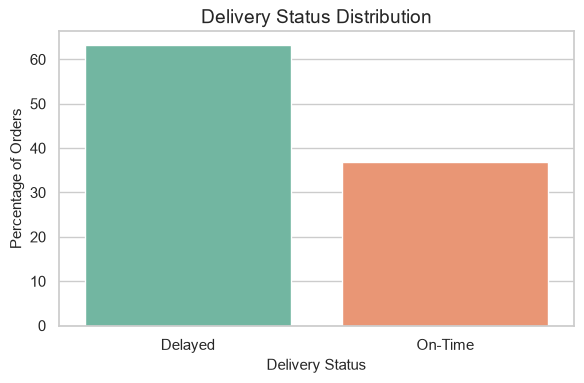

,delivery_status,percentage
0,Delayed,63.125
1,On-Time,36.875


In [7]:
status_counts = data["delivery_status"].value_counts(normalize=True).mul(100).reset_index()
status_counts.columns = ["delivery_status", "percentage"]

plt.figure(figsize=(6, 4))
sns.barplot(data=status_counts, x="delivery_status", y="percentage", hue="delivery_status", legend=False)
plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Percentage of Orders")
plt.tight_layout()
plt.show()

display(status_counts)

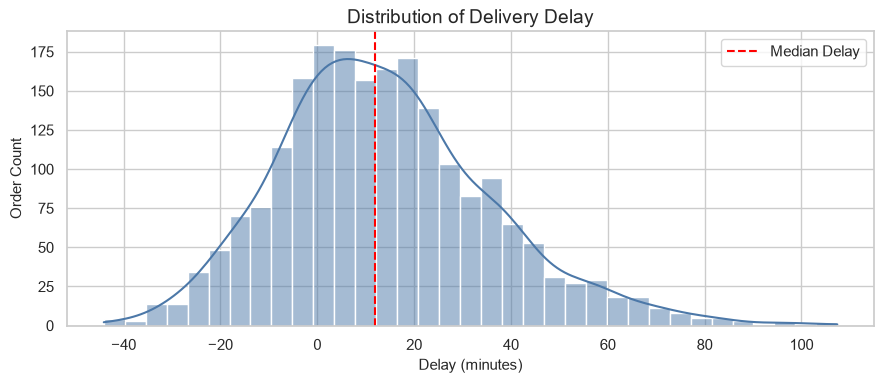

In [8]:
plt.figure(figsize=(9, 4))
sns.histplot(data=data, x="delay_mins", bins=35, kde=True, color="#4c78a8")
plt.axvline(data["delay_mins"].median(), color="red", linestyle="--", label="Median Delay")
plt.title("Distribution of Delivery Delay")
plt.xlabel("Delay (minutes)")
plt.ylabel("Order Count")
plt.legend()
plt.tight_layout()
plt.show()

# Root Cause Analysis

The following sections directly answer the challenge questions and identify operational root causes.

## Q1. Peak Hour Delay Pattern

Peak hours are defined as **8-10 AM** and **5-8 PM**. We compare peak-hour delays with off-peak delays and test whether the difference is statistically significant.

In [9]:
peak_delay_summary = data.groupby("time_period")["delay_mins"].agg(
    orders="count",
    average_delay="mean",
    median_delay="median"
).reset_index()

display(peak_delay_summary)

,time_period,orders,average_delay,median_delay
0,Off-Peak Hours,1211,7.381585,5.5
1,Peak Hours,869,23.245800,20.5


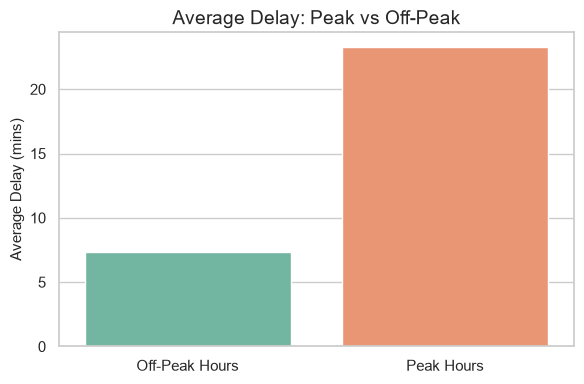

In [10]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=peak_delay_summary,
    x="time_period",
    y="average_delay",
    hue="time_period",
    legend=False,
    palette=["#66c2a5", "#fc8d62"]
)
plt.title("Average Delay: Peak vs Off-Peak")
plt.xlabel("")
plt.ylabel("Average Delay (mins)")
plt.tight_layout()
plt.show()

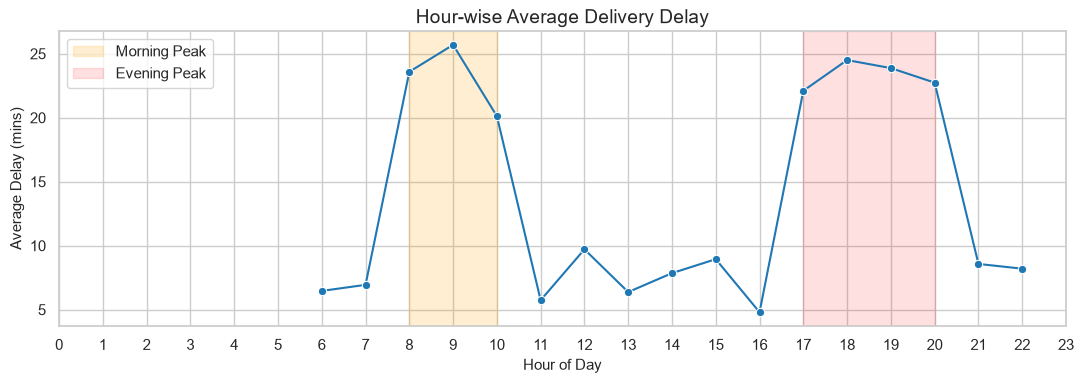

In [11]:
hourly_delay = data.groupby("hour")["delay_mins"].mean().reset_index()

plt.figure(figsize=(11, 4))
sns.lineplot(data=hourly_delay, x="hour", y="delay_mins", marker="o", color="#1f77b4")
plt.axvspan(8, 10, color="orange", alpha=0.18, label="Morning Peak")
plt.axvspan(17, 20, color="red", alpha=0.12, label="Evening Peak")
plt.title("Hour-wise Average Delivery Delay")
plt.xlabel("Hour of Day")
plt.ylabel("Average Delay (mins)")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
peak_delays = data.loc[data["time_period"] == "Peak Hours", "delay_mins"]
offpeak_delays = data.loc[data["time_period"] == "Off-Peak Hours", "delay_mins"]

t_stat, p_value = stats.ttest_ind(peak_delays, offpeak_delays, equal_var=False)

q1_results = pd.DataFrame({
    "Metric": ["Peak average delay", "Off-peak average delay", "Difference", "T-statistic", "P-value"],
    "Value": [
        round(peak_delays.mean(), 2),
        round(offpeak_delays.mean(), 2),
        round(peak_delays.mean() - offpeak_delays.mean(), 2),
        round(t_stat, 3),
        round(p_value, 5)
    ]
})

display(q1_results)

,Metric,Value
0,Peak average delay,23.250
1,Off-peak average delay,7.380
2,Difference,15.860
3,T-statistic,16.904
4,P-value,0.000


### Q1 Conclusion

Peak-hour orders have a much higher delay than off-peak orders. The average peak-hour delay is about **23.25 minutes**, compared with **7.38 minutes** during off-peak hours. The difference is about **15.86 minutes**.

The p-value is below 0.05, so the difference is statistically significant. This means peak-time delays are not random; they are likely caused by traffic, rider load, and order concentration during rush hours.

**Action:** Increase rider allocation and dispatch support during 8-10 AM and 5-8 PM.

## Q2. Weather vs Delay

This section compares median delay across weather conditions and identifies which order type is most affected by rain.

In [13]:
weather_delay = data.groupby("weather_condition")["delay_mins"].agg(
    orders="count",
    average_delay="mean",
    median_delay="median"
).reset_index().sort_values("median_delay", ascending=False)

display(weather_delay)

,weather_condition,orders,average_delay,median_delay
1,Fog,167,39.620958,37.9
3,Rain,422,31.323223,29.4
0,Clear,1091,6.462603,6.1
2,Partly Cloudy,400,5.634750,5.5


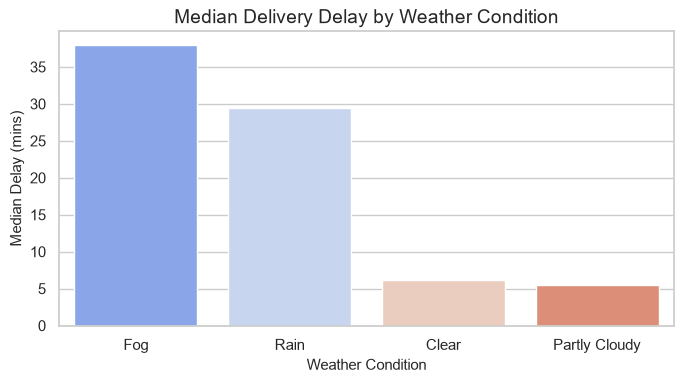

In [14]:
plt.figure(figsize=(7, 4))
sns.barplot(
    data=weather_delay,
    x="weather_condition",
    y="median_delay",
    hue="weather_condition",
    legend=False,
    palette="coolwarm"
)
plt.title("Median Delivery Delay by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Median Delay (mins)")
plt.tight_layout()
plt.show()

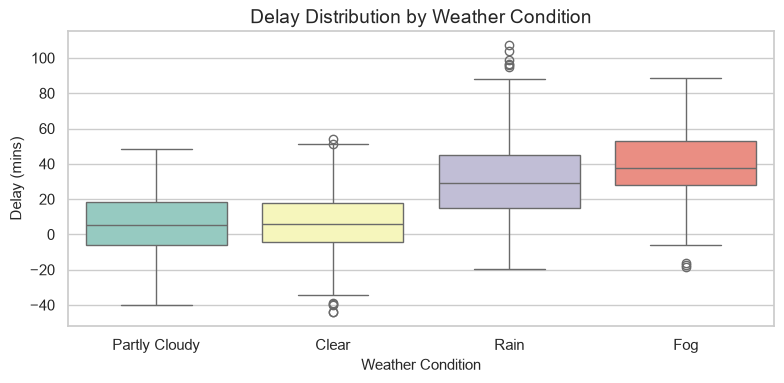

In [15]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=data,
    x="weather_condition",
    y="delay_mins",
    hue="weather_condition",
    legend=False,
    palette="Set3"
)
plt.title("Delay Distribution by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Delay (mins)")
plt.tight_layout()
plt.show()

In [16]:
rain_data = data[data["weather_condition"] == "Rain"]
rain_order_delay = rain_data.groupby("order_type")["delay_mins"].agg(
    orders="count",
    average_delay="mean",
    median_delay="median"
).reset_index().sort_values("median_delay", ascending=False)

display(rain_order_delay)

,order_type,orders,average_delay,median_delay
5,Medicine,66,34.413636,34.65
1,Documents,70,30.385714,29.80
3,Food,70,32.437143,29.20
4,Grocery,76,28.265789,29.05
2,Electronics,81,30.666667,28.80
0,Apparel,59,32.496610,27.10


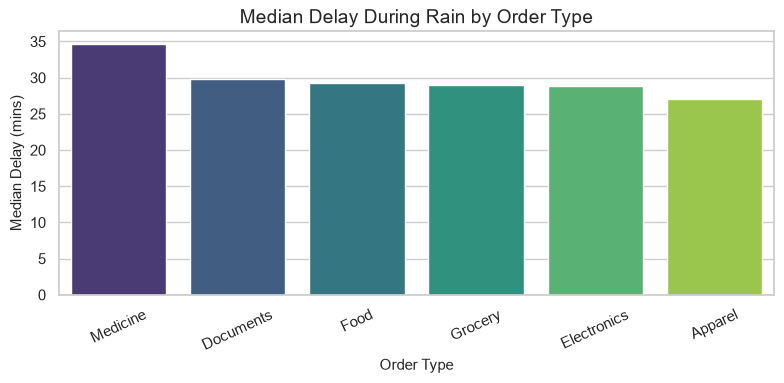

In [17]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=rain_order_delay,
    x="order_type",
    y="median_delay",
    hue="order_type",
    legend=False,
    palette="viridis"
)
plt.title("Median Delay During Rain by Order Type")
plt.xlabel("Order Type")
plt.ylabel("Median Delay (mins)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [18]:
weather_groups = [grp["delay_mins"].values for _, grp in data.groupby("weather_condition")]
h_stat, weather_p = stats.kruskal(*weather_groups)

print("Kruskal-Wallis statistic:", round(h_stat, 3))
print("P-value:", round(weather_p, 5))

Kruskal-Wallis statistic: 590.246
P-value: 0.0


### Q2 Conclusion

Weather has a strong relationship with delivery delay. Median delay is highest in **Fog (37.9 minutes)**, followed by **Rain (29.4 minutes)**. Clear and partly cloudy conditions have much lower median delays.

During rain, **Medicine** orders are hit hardest, with a median delay of about **34.65 minutes**.

The Kruskal-Wallis test checks whether delay distributions differ across weather conditions. A low p-value indicates that weather-related delay differences are statistically meaningful.

**Action:** Use weather-aware dispatching. During rain and fog, prioritize Medicine orders and assign experienced riders or faster vehicles.

## Q3. Rider Experience Effect

This section compares riders with **under 2 years** of experience against riders with **over 4 years** of experience.

In [19]:
def experience_group(years):
    if years < 2:
        return "Under 2 Years"
    if years > 4:
        return "Over 4 Years"
    return "2-4 Years"

data["experience_group"] = data["rider_experience_yrs"].apply(experience_group)

experience_delay = data.groupby("experience_group")["delay_mins"].agg(
    orders="count",
    average_delay="mean",
    median_delay="median"
).reset_index()

display(experience_delay)

,experience_group,orders,average_delay,median_delay
0,2-4 Years,565,13.580885,12.0
1,Over 4 Years,1065,14.348169,12.2
2,Under 2 Years,450,13.746000,11.6


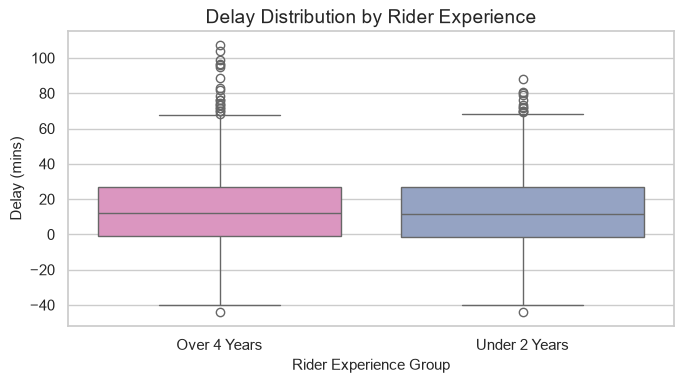

In [20]:
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=data[data["experience_group"].isin(["Under 2 Years", "Over 4 Years"])],
    x="experience_group",
    y="delay_mins",
    hue="experience_group",
    legend=False,
    palette=["#e78ac3", "#8da0cb"]
)
plt.title("Delay Distribution by Rider Experience")
plt.xlabel("Rider Experience Group")
plt.ylabel("Delay (mins)")
plt.tight_layout()
plt.show()

In [21]:
under_2 = data.loc[data["rider_experience_yrs"] < 2, "delay_mins"]
over_4 = data.loc[data["rider_experience_yrs"] > 4, "delay_mins"]

t_stat_exp, p_value_exp = stats.ttest_ind(under_2, over_4, equal_var=False)

q3_results = pd.DataFrame({
    "Metric": ["Under 2 years average delay", "Over 4 years average delay", "Difference", "T-statistic", "P-value"],
    "Value": [
        round(under_2.mean(), 2),
        round(over_4.mean(), 2),
        round(under_2.mean() - over_4.mean(), 2),
        round(t_stat_exp, 3),
        round(p_value_exp, 5)
    ]
})

display(q3_results)

,Metric,Value
0,Under 2 years average delay,13.75000
1,Over 4 years average delay,14.35000
2,Difference,-0.60000
3,T-statistic,-0.47500
4,P-value,0.63465


### Q3 Conclusion

Rider experience does not appear to be a major delay driver in this dataset. Riders under 2 years of experience have an average delay close to riders with over 4 years of experience.

If the p-value is greater than 0.05, the difference is not statistically significant. This means delay is more likely driven by external operational factors such as peak hours, weather, city conditions, and dispatch planning rather than rider experience alone.

## Additional Root Cause Views

These charts go beyond the required questions and help make the project stronger by identifying city, vehicle, and time-based patterns.

In [22]:
city_performance = data.groupby("city").agg(
    orders=("order_id", "count"),
    on_time_rate=("on_time_flag", "mean"),
    average_delay=("delay_mins", "mean")
).reset_index().sort_values("on_time_rate")

city_performance["on_time_rate_pct"] = city_performance["on_time_rate"] * 100
display(city_performance)

,city,orders,on_time_rate,average_delay,on_time_rate_pct
1,Bangalore,222,0.310811,15.104054,31.081081
3,Delhi,213,0.342723,14.664789,34.272300
0,Ahmedabad,236,0.347458,15.166525,34.745763
7,Lucknow,221,0.348416,15.806335,34.841629
6,Kolkata,192,0.348958,13.422396,34.895833
2,Chennai,193,0.357513,15.039896,35.751295
9,Pune,204,0.362745,13.585294,36.274510
8,Mumbai,203,0.384236,13.489163,38.423645
5,Jaipur,204,0.387255,12.900000,38.725490
4,Hyderabad,192,0.515625,10.257292,51.562500


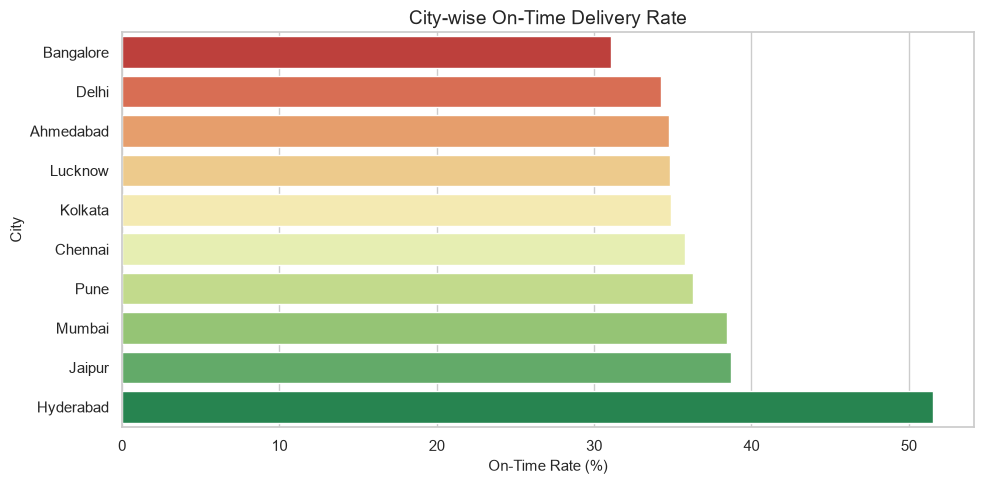

In [23]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=city_performance,
    x="on_time_rate_pct",
    y="city",
    hue="city",
    legend=False,
    palette="RdYlGn"
)
plt.title("City-wise On-Time Delivery Rate")
plt.xlabel("On-Time Rate (%)")
plt.ylabel("City")
plt.tight_layout()
plt.show()

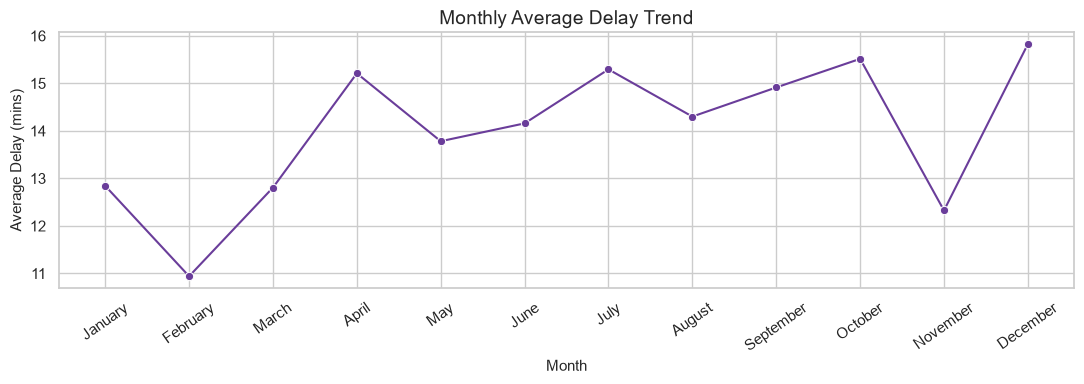

,month_num,month,delay_mins
0,1,January,12.842208
1,2,February,10.940000
2,3,March,12.806091
3,4,April,15.210345
4,5,May,13.781765
5,6,June,14.157471
6,7,July,15.293923
7,8,August,14.300568
8,9,September,14.913245
9,10,October,15.515152


In [24]:
monthly_delay = data.groupby(["month_num", "month"])["delay_mins"].mean().reset_index().sort_values("month_num")

plt.figure(figsize=(11, 4))
sns.lineplot(data=monthly_delay, x="month", y="delay_mins", marker="o", color="#6a3d9a")
plt.title("Monthly Average Delay Trend")
plt.xlabel("Month")
plt.ylabel("Average Delay (mins)")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

display(monthly_delay)

,vehicle_type,orders,on_time_rate,average_delay
0,Auto,615,0.349593,14.830244
3,Van,401,0.374065,14.408728
2,Cycle,399,0.343358,14.284211
1,Bike,665,0.398496,12.844812


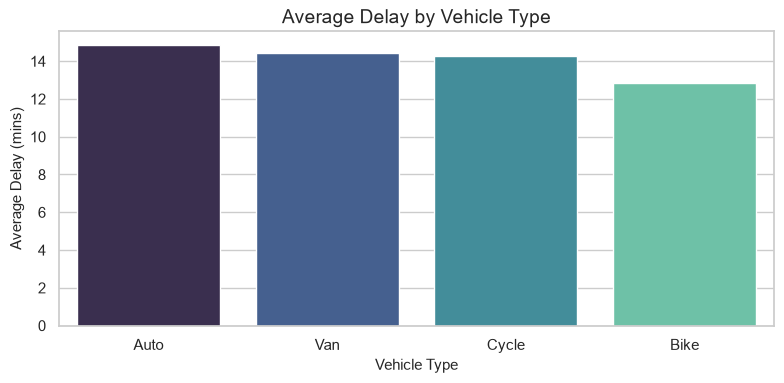

In [25]:
vehicle_performance = data.groupby("vehicle_type").agg(
    orders=("order_id", "count"),
    on_time_rate=("on_time_flag", "mean"),
    average_delay=("delay_mins", "mean")
).reset_index().sort_values("average_delay", ascending=False)

display(vehicle_performance)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=vehicle_performance,
    x="vehicle_type",
    y="average_delay",
    hue="vehicle_type",
    legend=False,
    palette="mako"
)
plt.title("Average Delay by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Delay (mins)")
plt.tight_layout()
plt.show()

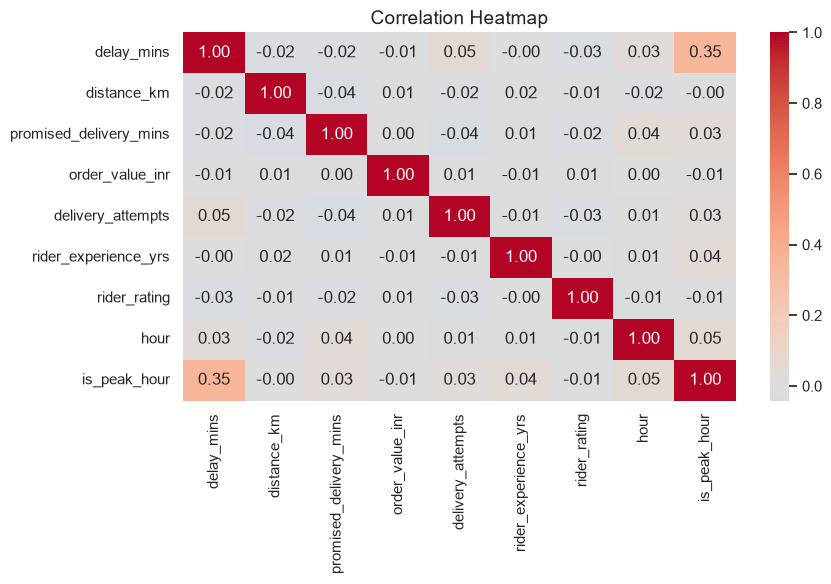

In [26]:
numeric_cols = [
    "delay_mins", "distance_km", "promised_delivery_mins", "order_value_inr",
    "delivery_attempts", "rider_experience_yrs", "rider_rating", "hour", "is_peak_hour"
]

plt.figure(figsize=(9, 6))
sns.heatmap(data[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Q4. City-Level Performance Dashboard

The dashboard combines the three requested views:

1. City-wise on-time rate
2. Monthly delay trend
3. Vehicle type comparison

An extra KPI panel is added to make the dashboard more executive-friendly.

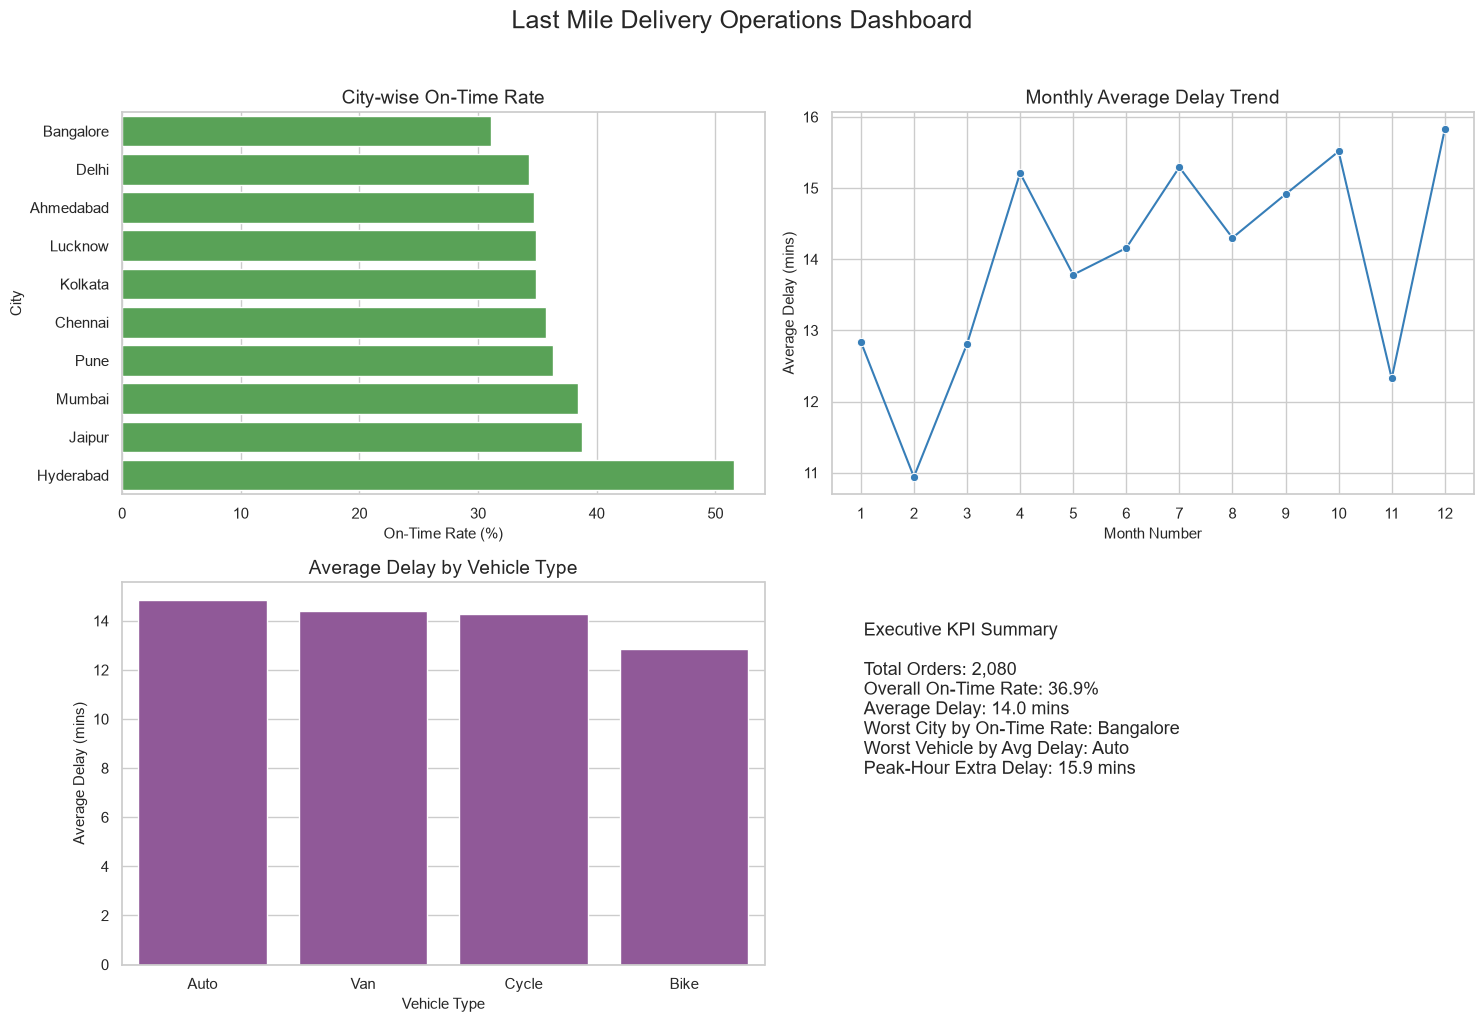

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel 1: City-wise on-time rate
sns.barplot(
    data=city_performance,
    x="on_time_rate_pct",
    y="city",
    ax=axes[0, 0],
    color="#4daf4a"
)
axes[0, 0].set_title("City-wise On-Time Rate")
axes[0, 0].set_xlabel("On-Time Rate (%)")
axes[0, 0].set_ylabel("City")

# Panel 2: Monthly delay trend
sns.lineplot(
    data=monthly_delay,
    x="month_num",
    y="delay_mins",
    marker="o",
    ax=axes[0, 1],
    color="#377eb8"
)
axes[0, 1].set_title("Monthly Average Delay Trend")
axes[0, 1].set_xlabel("Month Number")
axes[0, 1].set_ylabel("Average Delay (mins)")
axes[0, 1].set_xticks(range(1, 13))

# Panel 3: Vehicle comparison
sns.barplot(
    data=vehicle_performance,
    x="vehicle_type",
    y="average_delay",
    ax=axes[1, 0],
    color="#984ea3"
)
axes[1, 0].set_title("Average Delay by Vehicle Type")
axes[1, 0].set_xlabel("Vehicle Type")
axes[1, 0].set_ylabel("Average Delay (mins)")

# Panel 4: KPI summary
axes[1, 1].axis("off")
overall_on_time = data["on_time_flag"].mean() * 100
overall_avg_delay = data["delay_mins"].mean()
worst_city = city_performance.iloc[0]["city"]
worst_vehicle = vehicle_performance.iloc[0]["vehicle_type"]
peak_extra_delay = peak_delays.mean() - offpeak_delays.mean()

kpi_text = f"""
Executive KPI Summary

Total Orders: {len(data):,}
Overall On-Time Rate: {overall_on_time:.1f}%
Average Delay: {overall_avg_delay:.1f} mins
Worst City by On-Time Rate: {worst_city}
Worst Vehicle by Avg Delay: {worst_vehicle}
Peak-Hour Extra Delay: {peak_extra_delay:.1f} mins
"""
axes[1, 1].text(0.05, 0.95, kpi_text, va="top", ha="left", fontsize=13)

plt.suptitle("Last Mile Delivery Operations Dashboard", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

 Monthly Performance Trends

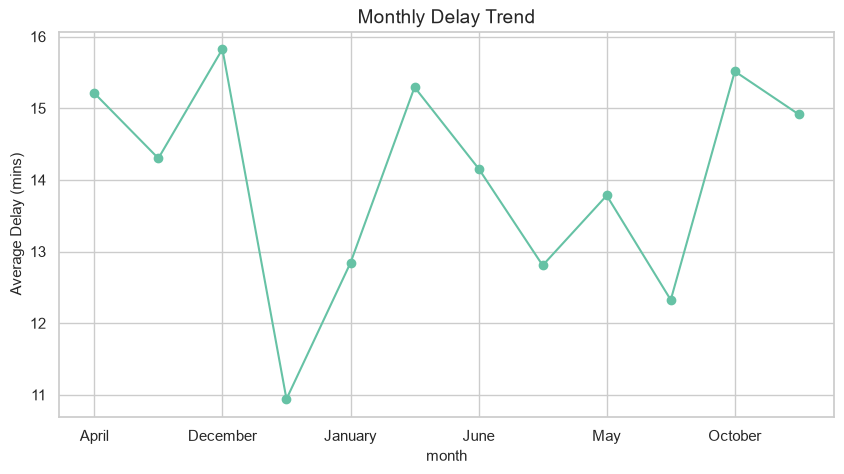

In [31]:
df['order_date'] = pd.to_datetime(df['order_date'])

df['month'] = df['order_date'].dt.month_name()

monthly_delay = df.groupby('month')['delay_mins'].mean()

monthly_delay.plot(marker='o', figsize=(10,5))
plt.title("Monthly Delay Trend")
plt.ylabel("Average Delay (mins)")
plt.show()

🚗 Vehicle Performance Analysis

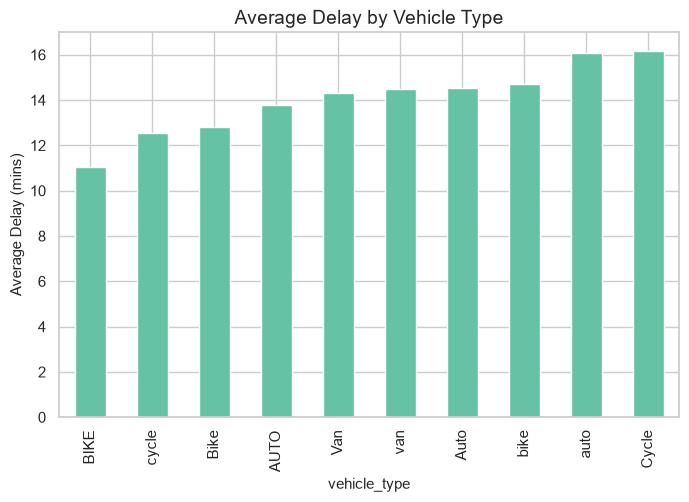

Fastest Vehicle: BIKE
Highest Delay Vehicle: Cycle


In [32]:
vehicle_delay = (
    df.groupby('vehicle_type')['delay_mins']
      .mean()
      .sort_values()
)

vehicle_delay.plot(kind='bar', figsize=(8,5))
plt.title("Average Delay by Vehicle Type")
plt.ylabel("Average Delay (mins)")
plt.show()

print("Fastest Vehicle:", vehicle_delay.idxmin())
print("Highest Delay Vehicle:", vehicle_delay.idxmax())

### Q4 Dashboard Recommendation

The single biggest operational fix is:

**Create a peak-hour and bad-weather dispatch plan that assigns extra riders and faster vehicles to high-risk cities and critical order types.**

Why this is the best fix:

- Peak-hour delay is statistically significant and adds about 16 minutes.
- Fog and rain sharply increase delivery delay.
- Medicine orders are most affected during rain.
- City-level performance shows some locations need targeted support.

This action is practical because it does not require changing the whole business model; it improves staffing and routing at the exact times and conditions where delays are highest.

## 6. Basic Machine Learning Model

The model predicts whether an order will be **Delayed** or **On-Time** using operational features available before or during dispatch.

This is a simple baseline model, not a production system. Its purpose is to demonstrate ML fundamentals and identify important delay signals.

In [28]:
features = [
    "city", "zone", "vehicle_type", "order_type", "weather_condition",
    "distance_km", "promised_delivery_mins", "order_value_inr",
    "delivery_attempts", "rider_experience_yrs", "rider_rating",
    "hour", "is_peak_hour", "is_weekend"
]

X = data[features]
y = data["delayed_flag"]

categorical_features = ["city", "zone", "vehicle_type", "order_type", "weather_condition"]
numeric_features = [col for col in features if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.738
ROC-AUC: 0.783

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.69      0.66       153
           1       0.81      0.76      0.79       263

    accuracy                           0.74       416
   macro avg       0.72      0.73      0.72       416
weighted avg       0.74      0.74      0.74       416



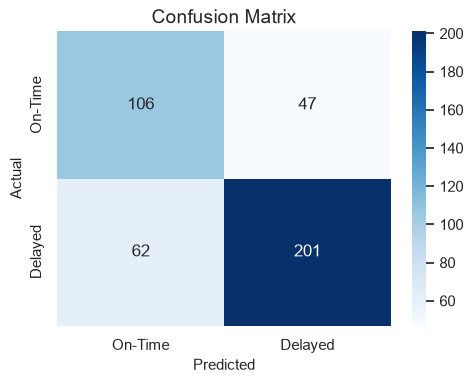

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["On-Time", "Delayed"], yticklabels=["On-Time", "Delayed"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

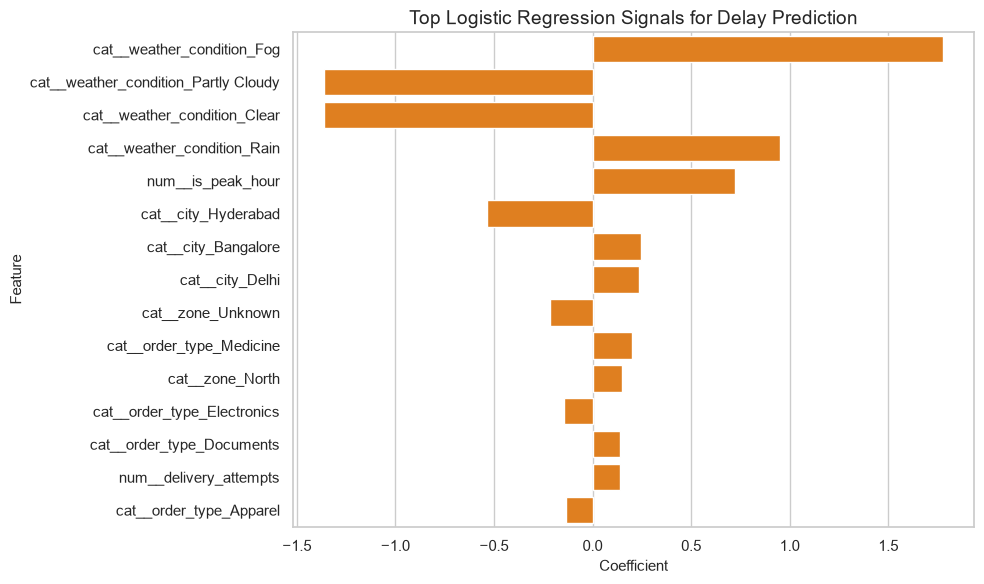

,feature,coefficient,abs_coefficient
27,cat__weather_condition_Fog,1.777824,1.777824
28,cat__weather_condition_Partly Cloudy,-1.362123,1.362123
26,cat__weather_condition_Clear,-1.359953,1.359953
29,cat__weather_condition_Rain,0.950775,0.950775
37,num__is_peak_hour,0.722444,0.722444
4,cat__city_Hyderabad,-0.534702,0.534702
1,cat__city_Bangalore,0.246975,0.246975
3,cat__city_Delhi,0.233373,0.233373
14,cat__zone_Unknown,-0.217772,0.217772
25,cat__order_type_Medicine,0.199582,0.199582


In [30]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["classifier"].coef_[0]

importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

importance["abs_coefficient"] = importance["coefficient"].abs()
top_features = importance.sort_values("abs_coefficient", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="coefficient", y="feature", color="#ff7f00")
plt.title("Top Logistic Regression Signals for Delay Prediction")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(top_features)

## Final Insights

1. **Peak hours are the strongest operational delay window.** Orders during peak hours are delayed by about 16 minutes more than off-peak orders.
2. **Weather is a major delay driver.** Fog has the highest median delay, followed by rain.
3. **Medicine orders are most affected during rain.** These should receive priority dispatch support.
4. **Rider experience is not the main root cause.** The statistical comparison shows only a small difference between low-experience and high-experience riders.
5. **City and vehicle performance vary.** This indicates that dispatch strategy should be city-specific rather than one-size-fits-all.

## Final Recommendation

The best single operational action is to implement a **risk-based dispatch plan**:

- Add rider capacity during 8-10 AM and 5-8 PM.
- Prioritize Medicine orders during rain and fog.
- Assign faster vehicles and experienced riders to high-risk weather/city combinations.
- Monitor city-level on-time rates weekly and rebalance rider supply.

This recommendation directly targets the strongest delay patterns found in the data and is practical for real-world delivery operations.